In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
import pandas as pd

# Upload file manually
uploaded = files.upload()

# Read the uploaded CSV
df = pd.read_csv("customers.csv")

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())

Saving customers.csv to customers.csv
  CustomerID  Age  Gender  Income  PurchaseAmount  PurchaseFrequency
0       C001   22  Female   25000            3000                  2
1       C002   35    Male   60000           15000                  6
2       C003   28  Female   45000            8000                  4
3       C004   42    Male   85000           25000                  9
4       C005   31  Female   52000           12000                  5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         50 non-null     object
 1   Age                50 non-null     int64 
 2   Gender             50 non-null     object
 3   Income             50 non-null     int64 
 4   PurchaseAmount     50 non-null     int64 
 5   PurchaseFrequency  50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None


In [3]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
PurchaseAmount,0
PurchaseFrequency,0


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [6]:
df.describe()

,Age,Income,PurchaseAmount,PurchaseFrequency
count,50.000000,50.000000,50.000000,50.000000
mean,36.920000,65440.000000,18146.000000,6.340000
std,10.716838,27862.021551,12173.896631,3.323448
min,21.000000,24000.000000,2800.000000,1.000000
25%,28.250000,42750.000000,7625.000000,3.250000
50%,35.000000,61000.000000,15250.000000,6.000000
75%,44.750000,89750.000000,27750.000000,9.000000
max,60.000000,120000.000000,45000.000000,13.000000


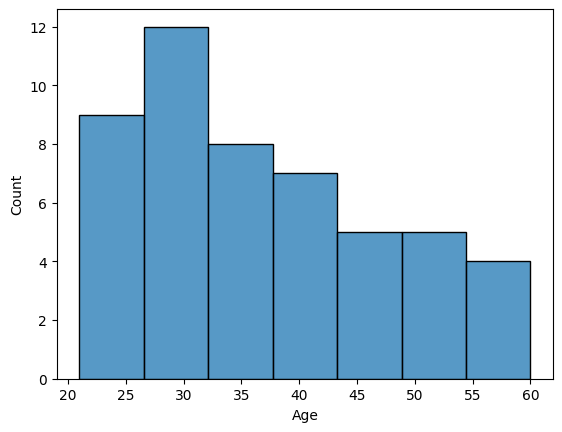

In [7]:
sns.histplot(df['Age'])
plt.show()

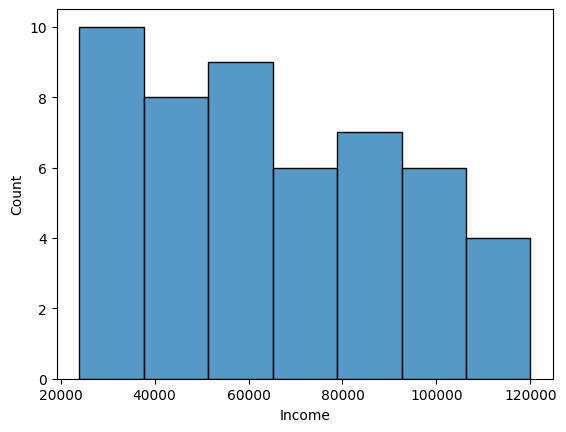

In [8]:
sns.histplot(df['Income'])
plt.show()

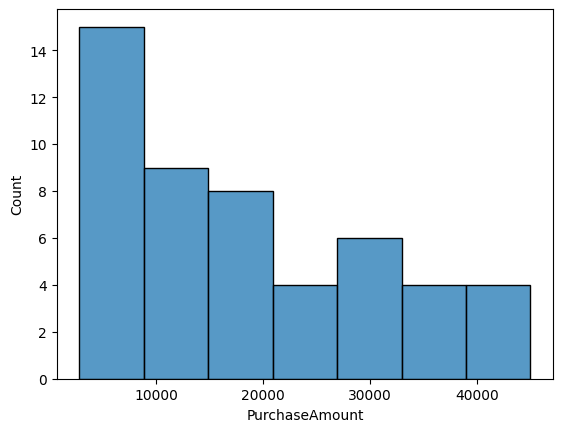

In [9]:
sns.histplot(df['PurchaseAmount'])
plt.show()

In [10]:
X = df[['Age',
        'Income',
        'PurchaseAmount',
        'PurchaseFrequency']]

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

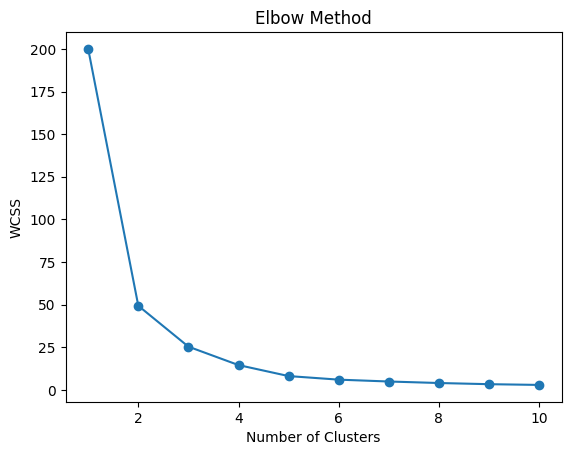

In [12]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

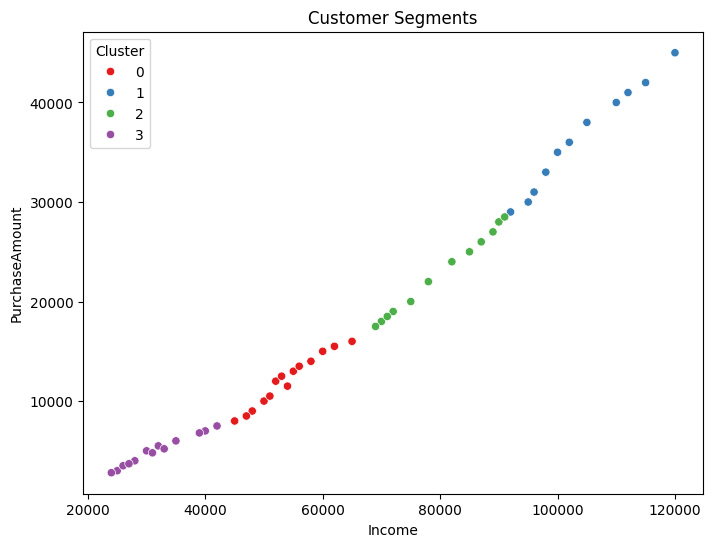

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='PurchaseAmount',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

In [15]:
segment_summary = df.groupby('Cluster').mean(numeric_only=True)

print(segment_summary)


               Age         Income  PurchaseAmount  PurchaseFrequency
Cluster                                                             
0        31.857143   54000.000000    12071.428571           4.857143
1        53.000000  104090.909091    36363.636364          11.090909
2        40.833333   79916.666667    22791.666667           7.916667
3        25.153846   31692.307692     4984.615385           2.461538


In [16]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [17]:

df.to_csv("customers_segmented.csv", index=False)

In [18]:
from google.colab import files

files.download("customers_segmented.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>